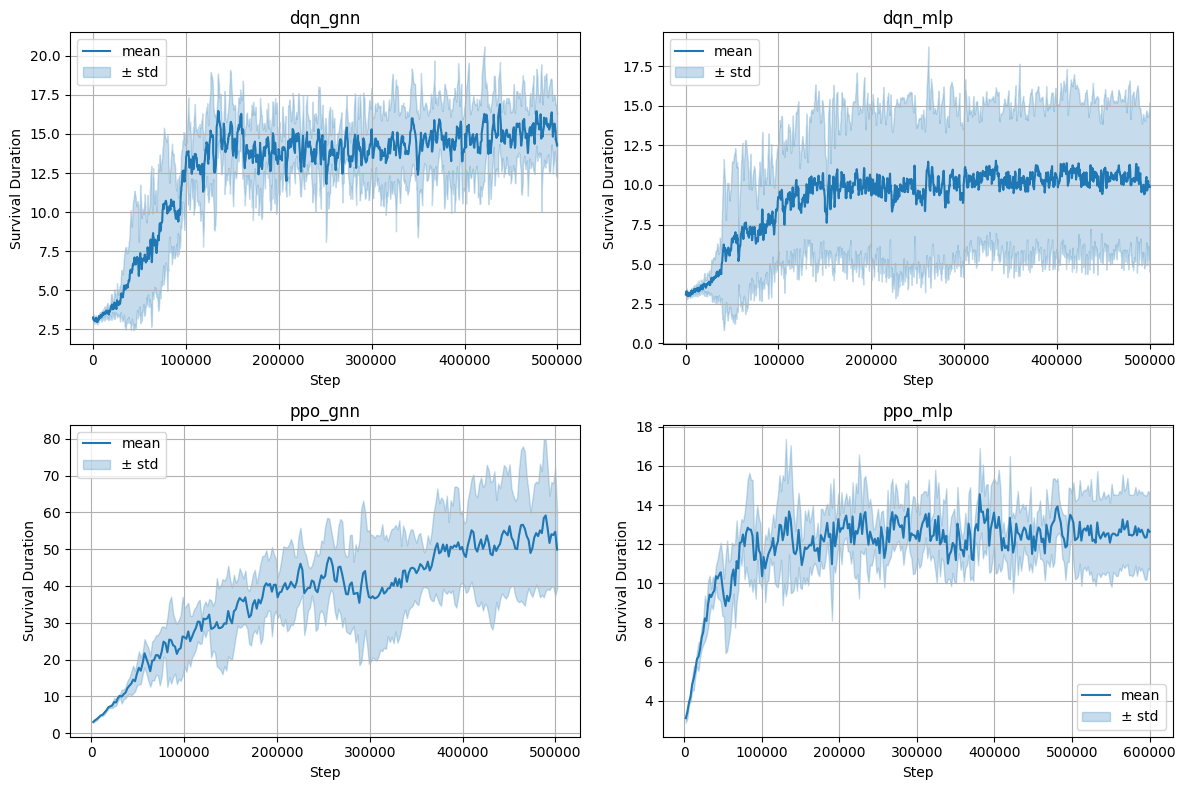

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../results/logs/downloads/"
files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
if not files:
    raise SystemExit(f"Keine CSV-Dateien in {DATA_DIR} gefunden.")

# Gruppiere Dateien nach baseline token wie "dqn_gnn", "ppo_mlp"
pattern = re.compile(r"relation-unaware-baselines_([a-zA-Z0-9]+_[a-zA-Z0-9]+)_")
groups = {}
for f in files:
    m = pattern.search(os.path.basename(f))
    if not m:
        continue
    key = m.group(1)
    groups.setdefault(key, []).append(f)

# Erwartet 4 Gruppen; falls weniger, nimmt vorhandene
baselines = sorted(groups.keys())
if not baselines:
    raise SystemExit("Keine passenden Baselines in Dateinamen gefunden.")

# Erzeuge 2x2 Plot (oder passend zur Anzahl Baselines)
n = len(baselines)
cols = 2
rows = (n + 1) // 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), squeeze=False)

for idx, baseline in enumerate(baselines):
    row, col = divmod(idx, cols)
    ax = axes[row][col]

    series_list = []
    for fp in groups[baseline]:
        df = pd.read_csv(fp)
        if "Step" not in df.columns or "Value" not in df.columns:
            continue
        s = df.set_index("Step")["Value"].sort_index()
        series_list.append(s)

    if not series_list:
        ax.set_title(baseline + " (keine Daten)")
        continue

    # Gemeinsame Steps (Vereinigung) und Interpolation für fehlende Werte
    common_steps = np.unique(np.concatenate([s.index.values for s in series_list]))
    aligned = pd.DataFrame(
        {f"run_{i}": s.reindex(common_steps).interpolate(limit_direction="both") for i, s in enumerate(series_list)}
    )

    mean = aligned.mean(axis=1)
    std = aligned.std(axis=1)

    ax.plot(common_steps, mean, label="mean", color="C0")
    ax.fill_between(common_steps, mean - std, mean + std, color="C0", alpha=0.25, label="± std")
    ax.set_xlabel("Step")
    ax.set_ylabel("Survival Duration")
    ax.set_title(baseline)
    ax.grid(True)
    ax.legend()

# Entferne leere Subplots falls n < rows*cols
for empty_idx in range(n, rows * cols):
    r, c = divmod(empty_idx, cols)
    fig.delaxes(axes[r][c])

fig.tight_layout()
plt.show()
# out_path = os.path.join(DATA_DIR, "training_progress.png")
# fig.savefig(out_path, dpi=150)
# print(f"Plot gespeichert in {out_path}")

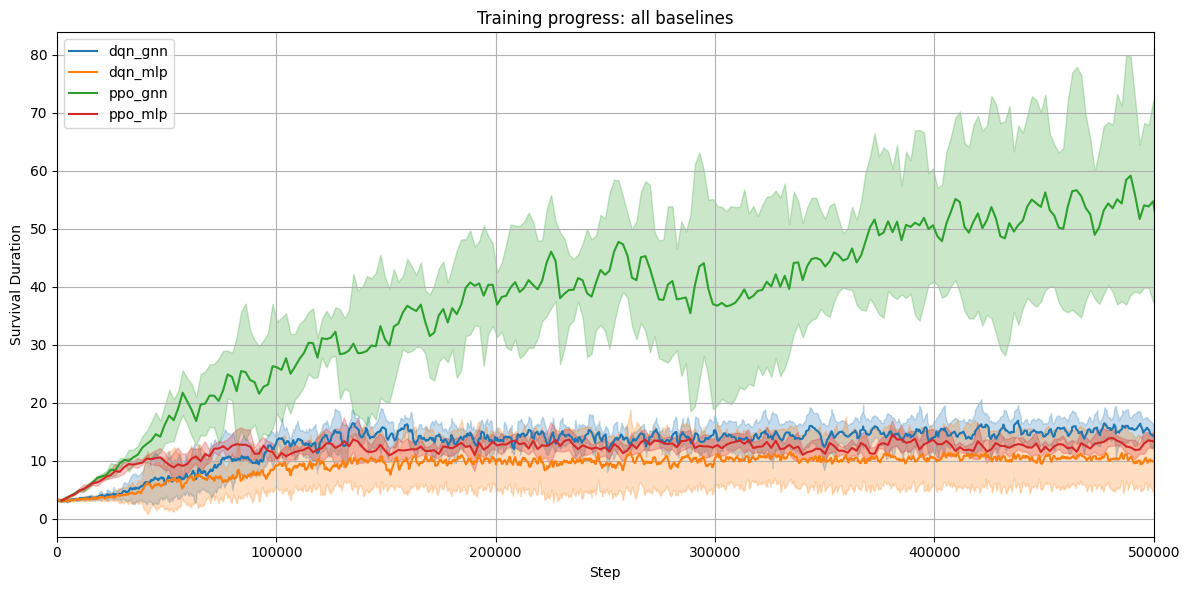

In [2]:
DATA_DIR = "../results/logs/downloads/"
files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
if not files:
    raise SystemExit(f"Keine CSV-Dateien in {DATA_DIR} gefunden.")

pattern = re.compile(r"relation-unaware-baselines_([a-zA-Z0-9]+_[a-zA-Z0-9]+)_")
groups = {}
for f in files:
    m = pattern.search(os.path.basename(f))
    if not m:
        continue
    key = m.group(1)
    groups.setdefault(key, []).append(f)

baselines = sorted(groups.keys())
if not baselines:
    raise SystemExit("Keine passenden Baselines in Dateinamen gefunden.")

fig, ax = plt.subplots(figsize=(12, 6))
color_cycle = plt.cm.tab10.colors  # genügend Farben für 4 Baselines

for i, baseline in enumerate(baselines):
    series_list = []
    for fp in groups[baseline]:
        df = pd.read_csv(fp)
        if "Step" not in df.columns or "Value" not in df.columns:
            continue
        s = df.set_index("Step")["Value"].sort_index()
        series_list.append(s)

    if not series_list:
        continue

    common_steps = np.unique(np.concatenate([s.index.values for s in series_list]))
    aligned = pd.DataFrame(
        {f"run_{j}": s.reindex(common_steps).interpolate(limit_direction="both") for j, s in enumerate(series_list)}
    )

    mean = aligned.mean(axis=1)
    std = aligned.std(axis=1)

    color = color_cycle[i % len(color_cycle)]
    ax.plot(common_steps, mean, label=baseline, color=color)
    ax.fill_between(common_steps, mean - std, mean + std, color=color, alpha=0.25)

ax.set_xlabel("Step")
ax.set_ylabel("Survival Duration")
ax.set_title("Training progress: all baselines")
ax.set_xlim(0, 500000)
ax.grid(True)
ax.legend()
fig.tight_layout()
plt.show()